# Bagged Decision Trees

Compare a single tree with a bootstrap ensemble.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from tree_model_utils import (
    FEATURES,
    compare_bagging,
    ensure_output_dir,
    fit_decision_tree,
    fit_signal_model,
    long_short_backtest,
    make_equity_panel,
    signal_quality,
    tune_random_forest,
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_equity_panel(seed=113)
comparison = compare_bagging(panel)
comparison.to_csv(OUTPUT / 'bagging_comparison.csv', index=False)
comparison

,model,rmse
0,single_tree,0.0346
1,bagging,0.0350


/var/folders/lc/bskvxbb93zs20ztn0vgyqs9c0000gn/T/ipykernel_64536/1856926764.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x='model', y='rmse', ax=ax, palette='viridis')


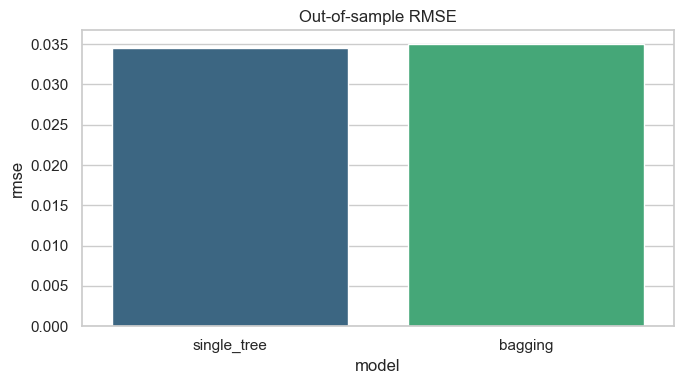

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=comparison, x='model', y='rmse', ax=ax, palette='viridis')
ax.set(title='Out-of-sample RMSE')
plt.tight_layout()